## Student Performance Indicator.

Life Cycle Of Machine Learning Project..

1. Understanding the Problem statement
2. Data collection
3. Data Checks to perform
4. Exploratory data analysis
5. Data Pre-processing
6. Model training
7. Choose best Model

1) Problem Statement..

- This project understands how the student's performance(test score) is affected by other variables such as gender,ethnicity,parental level of education,lunch and test preparation course.

2) Data collection

- Dataset source - https://www.kaggle.com/datasets/spscientist/students-performance-in
- The data consists of 8 columns and 1000 rows

2.1 Import data and required packages.

- Importing pandas,numpy,matplotlib,seaborn and warnins library.

In [1]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the csv file data as pandas dataframe

In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


3) Data Checks to perform

- Check missing values
- Check Duplicates
- Check Data types
- Check the number of unique values of each column
- Check statistics of dataset
- Check various categories present in the different categorical column

3.1 Check missing values

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

 3.2 Check Duplicates.

In [7]:
df.duplicated().sum()

0

3.3 Check Data types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


3.4 Checking the number of unique values of each column

In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

3.5 Check statistics of data set

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insight.

- From above description of numerical data,all means are very close to each other-between 66 and 68.05
- All standard deviations are also close - between 14.6 and 15.19
- while there is a minimum score 0 for math,for writing minimum is much higher = 10 and for reading myet higher = 17

3.7 Exploring data

In [12]:
print("Categories in 'gender' variables: ",end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variables: ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variables: ",end=" ")
print(df['parental level of education'].unique())

print("Categories in 'test preparation course' variables: ",end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variables:  ['female' 'male']
Categories in 'race/ethnicity' variables:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variables:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'test preparation course' variables:  ['none' 'completed']


In [13]:
## Define Numerical & Categorical columns.
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

## Print columns
print('We have {} numerical_features : {}'.format(len(numeric_features),numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features),categorical_features))

We have 3 numerical_features : ['math score', 'reading score', 'writing score']
We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


3.8 Adding columns for "Total score" and "Average"

In [14]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [26]:
reading_full = df[df['reading score']==100]['average'].count()
writing_full = df[df['writing score']==100]['average'].count()
math_full = df[df['math score']==100]['average'].count()

print(f'Number of students with full marks in maths: {math_full}')
print(f'Number of students with full marks in writing: {writing_full}')
print(f'Number of students with full marks in reading: {reading_full}')

Number of students with full marks in maths: 7
Number of students with full marks in writing: 14
Number of students with full marks in reading: 17


In [27]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in maths: {math_less_20}')
print(f'Number of students with less than 20 marks in reading: {reading_less_20}')
print(f'Number of students with less than 20 marks in writing: {writing_less_20}')

Number of students with less than 20 marks in maths: 4
Number of students with less than 20 marks in reading: 1
Number of students with less than 20 marks in writing: 3


Insights. 

- From above values we get students have performed the worst in Maths 
- Best performance is in reading section

4. Exploring Data (Visualization)

4.1 Visualize average score distribution to make some conclusion

- Histogram
- Kernel Distribution function(KDE)

4.1.1 Histogram & KDE

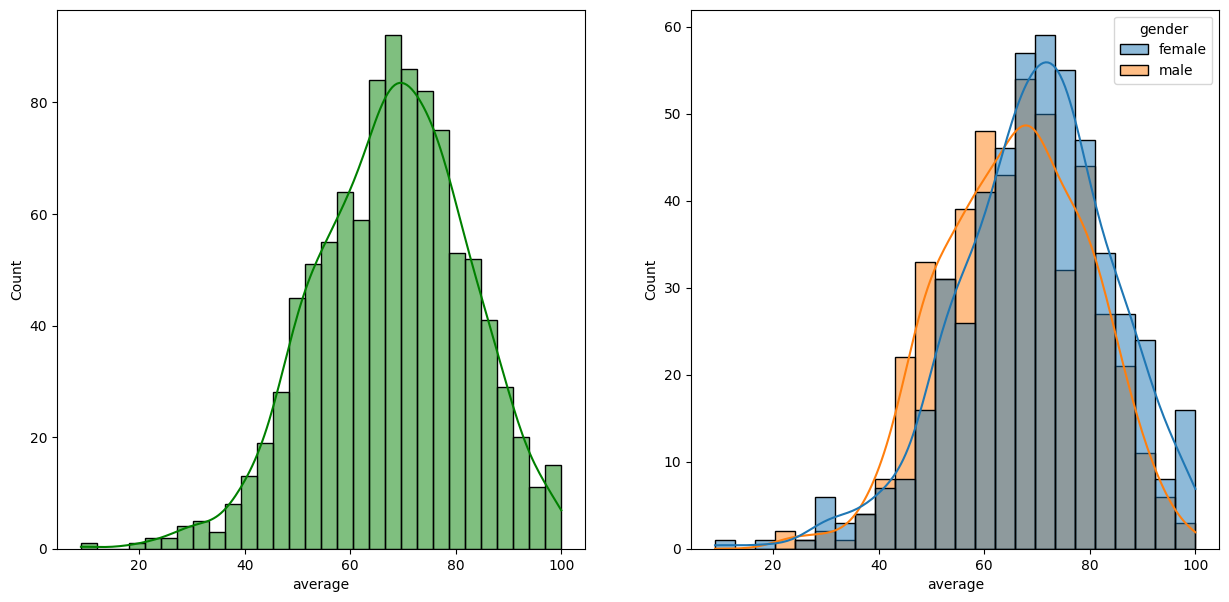

In [28]:
fig,axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

Insights

- Female students tend to perform well then male students

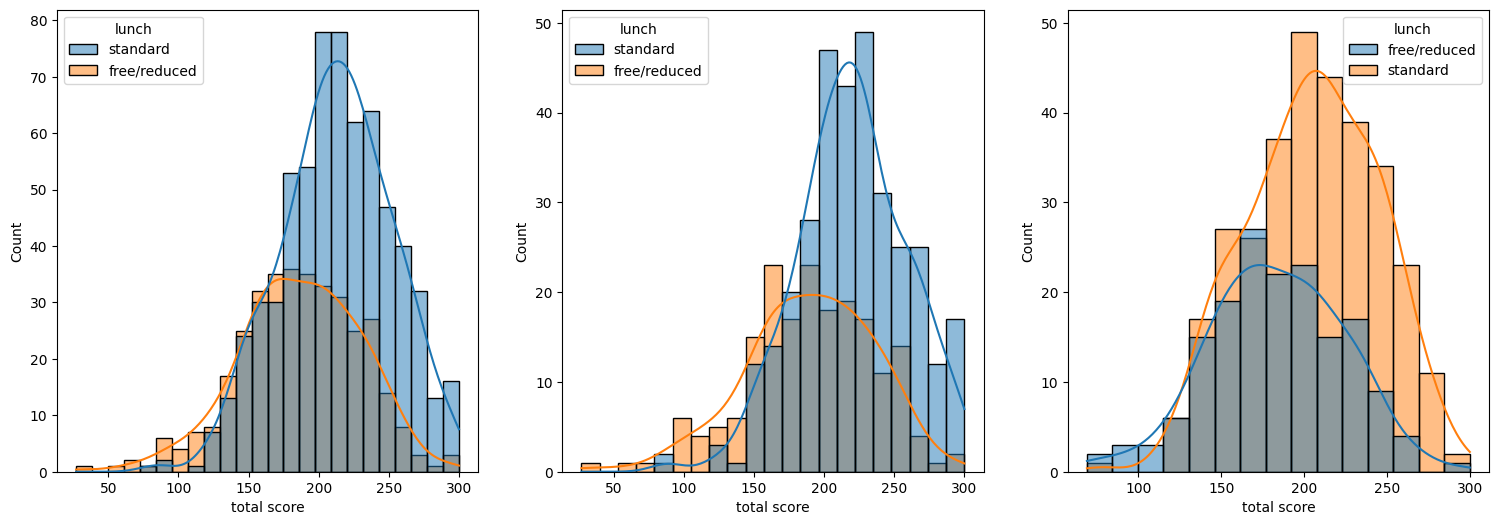

In [32]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='total score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='total score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='total score',kde=True,hue='lunch')
plt.show()